# Interactive team and player rating explorer

Explore the frozen global, map, agent, and player-conditional rating snapshots with editable display and ranking parameters.

This notebook is generated from immutable, hash-manifested artifacts. Any
counterfactual agent or composition result is predictive/associational,
not a causal estimate.

## Goal

This notebook provides a compact playground for the selected rating
snapshots. It includes global and per-map team rankings, per-map and
per-agent player leaderboards, and name-based player profiles.

The editable parameters change how frozen predictions are filtered and
ranked. They do **not** refit the model or constitute new model selection.

In [1]:
from pathlib import Path

SNAPSHOT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2")
DEVELOPMENT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full")
CONFIRMATION = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation")
SCORING_V5 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v5-ref-360cce8a5872")
SCORING_V4 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v4")
SCORING_V3 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3")
SCORING_V2 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v2")
SCORING_V1 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots")
SCORING = (
    SCORING_V5
    if SCORING_V5.exists()
    else (SCORING_V4 if SCORING_V4.exists() else (SCORING_V3 if SCORING_V3.exists() else (SCORING_V2 if SCORING_V2.exists() else SCORING_V1)))
)

print("snapshot:", SNAPSHOT)
print("development:", DEVELOPMENT if DEVELOPMENT.exists() else "not supplied")
print("confirmation:", CONFIRMATION if CONFIRMATION.exists() else "not available")
print("scoring:", SCORING if SCORING.exists() else "not available")

snapshot: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2
development: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full
confirmation: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation
scoring: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v5-ref-360cce8a5872


In [2]:
import sys

if sys.version_info[:2] != (3, 12):
    raise RuntimeError(
        "This notebook requires the 'Python 3.12 (Valorant Ratings)' kernel. "
        f"Current interpreter: {sys.executable} ({sys.version.split()[0]}). "
        "Use the notebook kernel picker, select the Valorant Ratings kernel, "
        "restart the kernel, and Run All."
    )

print("kernel:", sys.executable)
print("python:", sys.version.split()[0])

kernel: C:\Users\benja\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe
python: 3.12.13


## Setup

### 1. Edit exploration parameters

Run the notebook from the top after changing this cell. Conditional
player ratings are predictive associations, shown as both raw rounds per
24 and development-referenced z-scores. Keep uncertainty and support
visible when interpreting sparse combinations.

In [3]:
TOP_N = 10
PLAYER_METRIC = "performance_z_score"  # recommended display; raw is performance_rounds_per_24
PLAYER_AGENT_VIEW = "demonstrated"  # or "forced-counterfactual"
PLAYER_UNCERTAINTY_PENALTY = 0.5     # score = mean - penalty * SD
TEAM_UNCERTAINTY_PENALTY = 0.0       # applied to Elo rating rankings
ALLOWED_SUPPORT = ("observed", "partially-pooled", "extrapolated")
MIN_AGENT_USE_PROBABILITY = 0.0

PLAYER_QUERY = "something"          # case-insensitive IGN, slug, or player_id
MAP_QUERY = "Ascent"
AGENT_QUERY = "Jett"
ROUND_DIGITS = 4

print("Configured player-agent view:", PLAYER_AGENT_VIEW)
print("Edit these values, then choose Run All Above or restart the kernel and Run All.")

Configured player-agent view: demonstrated
Edit these values, then choose Run All Above or restart the kernel and Run All.


### Key assumptions

- The snapshot is standardized to the current patch and current complete
  five-player rosters at the recorded cutoff.
- Global team rank is mean pairwise map-win probability against the other
  active teams, averaged equally over the active maps; it is not a
  tournament-win probability.
- A player map rating fixes the map and marginalizes over predicted legal
  agents. An agent rating fixes the agent and equally averages active maps.
- The default player-agent leaderboard is `demonstrated`, which requires at
  least one map on that agent in the configured recency window. The
  `forced-counterfactual` view is the explicitly flagged full grid.
- `performance_rounds_per_24` (and its compatibility alias
  `performance_mean`) is the raw Predictive Box VPM association in signed
  rounds per 24 played rounds. `performance_z_score` standardizes that raw
  value within each view against arithmetic means of observed rolling
  2024-2025 OOF contexts. It is an empirical display reference, not a
  reconstruction of the current map-pool or agent-selection weights; a
  0.1 z-score difference is only one tenth of that reference SD.
- `contribution_mean` currently equals performance because separately
  identified contribution updates were not promoted.

In [4]:
import difflib
import json
import sys
from numbers import Integral

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Make the local research package importable even when this notebook is
# opened with a Jupyter/VS Code kernel that did not install it editable.
RATINGS_WORKSPACE = SNAPSHOT.parents[2]
SOURCE_ROOT = RATINGS_WORKSPACE / "src"
if not SOURCE_ROOT.is_dir():
    raise FileNotFoundError(f"ratings source directory not found: {SOURCE_ROOT}")
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from valorant_ratings.artifacts import verify_artifact_store

if not SCORING.exists():
    raise FileNotFoundError("Run the batch-scoring command before opening this notebook")

scoring_manifest = verify_artifact_store(SCORING)
snapshot_manifest = json.loads((SNAPSHOT / "manifest.json").read_text(encoding="utf-8"))

team_directory = pd.read_parquet(SNAPSHOT / "teams.parquet").rename(
    columns={"name": "team_name", "slug": "team_slug"}
)
player_directory_all = pd.read_parquet(SNAPSHOT / "players.parquet").rename(
    columns={"ign": "player_name", "name": "player_full_name", "slug": "player_slug"}
)
def _bridge_legacy_vpm_units(frame):
    # Convert pre-v5 normalized-margin player outputs to rounds/24.
    if "performance_z_score" in frame.columns:
        return frame
    result = frame.copy()
    for column in (
        "performance_mean",
        "contribution_mean",
        "standard_deviation",
        "interval80_low",
        "interval80_high",
        "interval95_low",
        "interval95_high",
        "ranking_score",
    ):
        if column in result:
            result[column] = pd.to_numeric(result[column], errors="raise") * 24.0
    if "performance_mean" in result:
        result["performance_rounds_per_24"] = result["performance_mean"]
    return result


field_rankings_raw = pd.read_parquet(SCORING / "field_rankings.parquet")
team_ratings_raw = pd.read_parquet(SCORING / "team_ratings.parquet")
player_ratings_raw = _bridge_legacy_vpm_units(
    pd.read_parquet(SCORING / "player_ratings.parquet")
)
agent_probabilities = pd.read_parquet(SCORING / "agent_selection_probabilities.parquet")
if (
    PLAYER_METRIC == "performance_z_score"
    and "performance_z_score" not in player_ratings_raw.columns
):
    PLAYER_METRIC = "performance_rounds_per_24"
    print(
        "WARNING: this legacy scoring bundle has no development-referenced "
        "z-scores; converting its normalized-margin values by 24 and "
        "falling back to raw rounds per 24."
    )

player_agent_paths = {
    "demonstrated": SCORING / "player_agent_ratings_demonstrated.parquet",
    "forced-counterfactual": SCORING / "player_agent_ratings_forced_counterfactual.parquet",
}
if all(path.exists() for path in player_agent_paths.values()):
    player_agent_ratings_raw_by_view = {
        view: _bridge_legacy_vpm_units(pd.read_parquet(path))
        for view, path in player_agent_paths.items()
    }
    PLAYER_AGENT_ARTIFACT_MODE = (
        "dedicated-v5"
        if "performance_z_score" in player_ratings_raw.columns
        else "dedicated-v4"
    )
else:
    # Legacy bundles published only one unqualified agent grid. Preserve
    # access to it as explicitly forced-counterfactual; a demonstrated
    # leaderboard requires the v4 recency-windowed artifact.
    legacy_agent_ratings = player_ratings_raw.loc[
        player_ratings_raw["view"].eq("agent")
    ].copy()
    if "publication_view" in legacy_agent_ratings:
        player_agent_ratings_raw_by_view = {
            view: legacy_agent_ratings.loc[
                legacy_agent_ratings["publication_view"].eq(view)
            ].copy()
            for view in ("demonstrated", "forced-counterfactual")
            if legacy_agent_ratings["publication_view"].eq(view).any()
        }
    else:
        legacy_agent_ratings["publication_view"] = "forced-counterfactual"
        legacy_agent_ratings["is_default_view"] = False
        legacy_agent_ratings["is_forced_counterfactual"] = True
        player_agent_ratings_raw_by_view = {
            "forced-counterfactual": legacy_agent_ratings
        }
    PLAYER_AGENT_ARTIFACT_MODE = "legacy-single-grid"

print("snapshot cutoff:", snapshot_manifest["cutoff"])
print("ratings source:", SOURCE_ROOT)
print("snapshot data sha256:", snapshot_manifest["data_sha256"])
print("scoring experiment:", scoring_manifest["experiment_id"])
print("scoring manifest sha256:", scoring_manifest["manifest_digest"])

snapshot cutoff: 2026-06-21T23:59:59.999999+00:00
ratings source: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\src
snapshot data sha256: 97e36e8f5eb4c2cfa448adf466a47983094f08593f1b9f9b3a2f4efbc98caef9
scoring experiment: ratings-development-v1-full__rating-snapshots-v5-ref-360cce8a5872
scoring manifest sha256: 6ae5a121c4b6b603378bf101905ca6d90c7f37255c0d90c85b18f85f9436520c


In [5]:
def _nonblank(series):
    values = series.astype("string").str.strip()
    return values.mask(values.eq(""))


player_directory_all["player_name"] = (
    _nonblank(player_directory_all["player_name"])
    .fillna(_nonblank(player_directory_all["player_full_name"]))
    .fillna("Player " + player_directory_all["player_id"].astype(str))
)
team_directory["team_name"] = (
    _nonblank(team_directory["team_name"])
    .fillna(_nonblank(team_directory["team_slug"]))
    .fillna("Team " + team_directory["team_id"].astype(str))
)

team_names = team_directory[["team_id", "team_name", "team_slug"]].drop_duplicates("team_id")
player_names = player_directory_all[
    ["player_id", "player_name", "player_full_name", "player_slug"]
].drop_duplicates("player_id")

team_ratings = team_ratings_raw.merge(
    team_names, on="team_id", how="left", validate="many_to_one"
)
overall_teams = team_ratings.loc[
    team_ratings["view"].eq("overall"),
    ["team_id", "rating", "uncertainty"],
]
global_teams = (
    field_rankings_raw.merge(overall_teams, on="team_id", validate="one_to_one")
    .merge(team_names, on="team_id", how="left", validate="many_to_one")
)

active_player_teams = player_ratings_raw[["player_id", "team_id"]].drop_duplicates()
active_player_directory = (
    active_player_teams.merge(player_names, on="player_id", how="left", validate="many_to_one")
    .merge(team_names, on="team_id", how="left", validate="many_to_one")
)
player_ratings = (
    player_ratings_raw.merge(player_names, on="player_id", how="left", validate="many_to_one")
    .merge(team_names, on="team_id", how="left", validate="many_to_one")
)
mean_agent_use = (
    agent_probabilities.groupby(["player_id", "team_id", "agent"], as_index=False)
    .agg(predicted_agent_use_probability=("probability", "mean"))
)

def _prepare_player_agent_view(publication_view, frame):
    prepared = frame.copy()
    if "predicted_agent_use_probability" not in prepared:
        prepared = prepared.merge(
            mean_agent_use,
            on=["player_id", "team_id", "agent"],
            how="left",
            validate="many_to_one",
        )
    if "maps_played" not in prepared:
        prepared["maps_played"] = np.nan
    prepared["publication_view"] = publication_view
    if "is_default_view" not in prepared:
        prepared["is_default_view"] = publication_view == "demonstrated"
    if "is_forced_counterfactual" not in prepared:
        prepared["is_forced_counterfactual"] = publication_view == "forced-counterfactual"
    return (
        prepared.merge(player_names, on="player_id", how="left", validate="many_to_one")
        .merge(team_names, on="team_id", how="left", validate="many_to_one")
    )


player_agent_ratings_by_view = {
    view: _prepare_player_agent_view(view, frame)
    for view, frame in player_agent_ratings_raw_by_view.items()
}
PLAYER_AGENT_VIEWS = tuple(player_agent_ratings_by_view)
if PLAYER_AGENT_VIEW in player_agent_ratings_by_view:
    ACTIVE_PLAYER_AGENT_VIEW = PLAYER_AGENT_VIEW
elif "forced-counterfactual" in player_agent_ratings_by_view:
    ACTIVE_PLAYER_AGENT_VIEW = "forced-counterfactual"
    print(
        "WARNING: demonstrated player-agent ratings are unavailable in this "
        "legacy bundle; using the explicitly forced-counterfactual grid."
    )
else:
    raise ValueError("the scoring bundle contains no usable player-agent publication view")
player_agent_ratings_raw = pd.concat(
    player_agent_ratings_raw_by_view.values(), ignore_index=True, sort=False
)
player_agent_ratings = pd.concat(
    player_agent_ratings_by_view.values(), ignore_index=True, sort=False
)

ACTIVE_MAPS = tuple(team_ratings.loc[team_ratings["view"].eq("map"), "map_name"].drop_duplicates())
agent_directory_view = (
    "forced-counterfactual"
    if "forced-counterfactual" in player_agent_ratings_by_view
    else ACTIVE_PLAYER_AGENT_VIEW
)
LEGAL_AGENTS = tuple(
    player_agent_ratings_by_view[agent_directory_view]["agent"].drop_duplicates()
)
SUPPORT_VALUES = ("observed", "partially-pooled", "extrapolated")

print(f"loaded {len(global_teams)} teams and {active_player_directory['player_id'].nunique()} players")
print("active maps:", ", ".join(ACTIVE_MAPS))
print("legal agents:", ", ".join(LEGAL_AGENTS))
print("player-agent artifact mode:", PLAYER_AGENT_ARTIFACT_MODE)
print("Active player-agent view:", ACTIVE_PLAYER_AGENT_VIEW)

loaded 48 teams and 240 players
active maps: Ascent, Breeze, Fracture, Haven, Lotus, Pearl, Split
legal agents: Astra, Breach, Brimstone, Chamber, Clove, Cypher, Deadlock, Fade, Gekko, Harbor, Iso, Jett, KAY/O, Killjoy, Miks, Neon, Omen, Phoenix, Raze, Reyna, Sage, Skye, Sova, Tejo, Veto, Viper, Vyse, Waylay, Yoru
player-agent artifact mode: dedicated-v5
Active player-agent view: demonstrated


## Steps

### 2. Reusable ranking and lookup functions

Functions return ordinary DataFrames, so you can filter, chart, or export
their results in additional cells without changing the source artifacts.

In [6]:
def _positive_n(n):
    value = TOP_N if n is None else int(n)
    if value <= 0:
        raise ValueError("n must be positive")
    return value


def _player_metric(metric):
    value = PLAYER_METRIC if metric is None else str(metric)
    allowed = {
        "performance_z_score",
        "performance_rounds_per_24",
        "performance_mean",
        "contribution_mean",
    }
    if value not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")
    return value


def _allowed_support(values):
    allowed = tuple(ALLOWED_SUPPORT if values is None else values)
    unknown = set(allowed).difference(SUPPORT_VALUES)
    if unknown:
        raise ValueError(f"unknown support values: {sorted(unknown)}")
    if not allowed:
        raise ValueError("allowed_support cannot be empty")
    return allowed


def _player_agent_view(value):
    selected = ACTIVE_PLAYER_AGENT_VIEW if value is None else str(value).strip()
    if selected not in player_agent_ratings_by_view:
        raise ValueError(
            f"unknown or unavailable player-agent view {selected!r}; "
            f"choose one of {PLAYER_AGENT_VIEWS}"
        )
    return selected


def _resolve_label(value, choices, label):
    text = str(value).strip()
    matches = [choice for choice in choices if str(choice).casefold() == text.casefold()]
    if len(matches) == 1:
        return matches[0]
    suggestions = difflib.get_close_matches(text, list(map(str, choices)), n=5, cutoff=0.3)
    hint = f" Close matches: {', '.join(suggestions)}" if suggestions else ""
    raise ValueError(f"unknown {label} {value!r}.{hint}")


def resolve_player(name_or_id):
    directory = active_player_directory.copy()
    if isinstance(name_or_id, Integral):
        matches = directory.loc[directory["player_id"].eq(int(name_or_id))]
    else:
        query = str(name_or_id).strip().casefold()
        exact = np.zeros(len(directory), dtype=bool)
        for column in ("player_name", "player_full_name", "player_slug"):
            exact |= directory[column].astype("string").fillna("").str.casefold().eq(query).to_numpy()
        matches = directory.loc[exact]
        if matches.empty:
            contains = np.zeros(len(directory), dtype=bool)
            for column in ("player_name", "player_full_name", "player_slug"):
                contains |= directory[column].astype("string").fillna("").str.casefold().str.contains(
                    query, regex=False
                ).to_numpy()
            matches = directory.loc[contains]
    if len(matches) == 1:
        return matches.iloc[0]
    if matches.empty:
        suggestions = difflib.get_close_matches(
            str(name_or_id), directory["player_name"].astype(str).tolist(), n=8, cutoff=0.25
        )
        hint = f" Suggestions: {', '.join(suggestions)}" if suggestions else ""
        raise ValueError(f"no active player matched {name_or_id!r}.{hint}")
    candidates = matches[["player_id", "player_name", "team_name"]].sort_values(
        ["player_name", "team_name"], kind="stable"
    )
    raise ValueError(
        "ambiguous player query; use player_id:\n" + candidates.to_string(index=False)
    )


def top_teams_global(n=None, method="field", uncertainty_penalty=None):
    limit = _positive_n(n)
    penalty = TEAM_UNCERTAINTY_PENALTY if uncertainty_penalty is None else float(uncertainty_penalty)
    work = global_teams.copy()
    if method == "field":
        work["ranking_score"] = work["field_win_probability"]
        work = work.sort_values(["ranking_score", "team_name"], ascending=[False, True], kind="stable")
    elif method == "rating":
        work["ranking_score"] = work["rating"] - penalty * work["uncertainty"]
        work = work.sort_values(["ranking_score", "team_name"], ascending=[False, True], kind="stable")
    else:
        raise ValueError("method must be 'field' or 'rating'")
    work["display_rank"] = np.arange(1, len(work) + 1)
    return work.head(limit)[
        ["display_rank", "rank", "team_id", "team_name", "team_slug",
         "field_win_probability", "rating", "uncertainty", "ranking_score"]
    ].reset_index(drop=True)


def top_teams_by_map(map_name=None, n=None, uncertainty_penalty=None):
    limit = _positive_n(n)
    penalty = TEAM_UNCERTAINTY_PENALTY if uncertainty_penalty is None else float(uncertainty_penalty)
    work = team_ratings.loc[team_ratings["view"].eq("map")].copy()
    if map_name is not None:
        resolved = _resolve_label(map_name, ACTIVE_MAPS, "map")
        work = work.loc[work["map_name"].eq(resolved)]
    work["ranking_score"] = work["rating"] - penalty * work["uncertainty"]
    work = work.sort_values(
        ["map_name", "ranking_score", "team_name"], ascending=[True, False, True], kind="stable"
    )
    work["map_rank"] = work.groupby("map_name").cumcount() + 1
    return work.loc[work["map_rank"].le(limit),
        ["map_name", "map_rank", "team_id", "team_name", "team_slug",
         "rating", "uncertainty", "ranking_score"]
    ].reset_index(drop=True)


def _rank_player_view(view, group_column, metric=None, allowed_support=None,
                      uncertainty_penalty=None, min_agent_use_probability=0.0,
                      agent_view=None):
    selected_metric = _player_metric(metric)
    allowed = _allowed_support(allowed_support)
    penalty = (
        PLAYER_UNCERTAINTY_PENALTY
        if uncertainty_penalty is None
        else float(uncertainty_penalty)
    )
    if view == "agent":
        selected_agent_view = _player_agent_view(agent_view)
        work = player_agent_ratings_by_view[selected_agent_view].loc[
            lambda frame: frame["support"].isin(allowed)
        ].copy()
        work = work.loc[
            work["predicted_agent_use_probability"].fillna(0.0).ge(float(min_agent_use_probability))
        ]
    else:
        work = player_ratings.loc[
            player_ratings["view"].eq(view) & player_ratings["support"].isin(allowed)
        ].copy()
    uncertainty_column = (
        "standard_deviation_z"
        if selected_metric == "performance_z_score"
        else "standard_deviation"
    )
    work["ranking_score"] = work[selected_metric] - penalty * work[uncertainty_column]
    work = work.sort_values(
        [group_column, "ranking_score", "player_name", "player_id"],
        ascending=[True, False, True, True],
        kind="stable",
    )
    work["conditional_rank"] = work.groupby(group_column).cumcount() + 1
    return work, selected_metric


def top_players_by_map(map_name=None, n=None, metric=None, allowed_support=None,
                       uncertainty_penalty=None):
    limit = _positive_n(n)
    work, selected_metric = _rank_player_view(
        "map", "map_name", metric, allowed_support, uncertainty_penalty
    )
    if map_name is not None:
        resolved = _resolve_label(map_name, ACTIVE_MAPS, "map")
        work = work.loc[work["map_name"].eq(resolved)]
    columns = [
        "map_name", "conditional_rank", "player_id", "player_name", "team_name",
        selected_metric, "performance_rounds_per_24", "performance_z_score",
        "standard_deviation", "standard_deviation_z", "interval80_low", "interval80_high",
        "support", "ranking_score",
    ]
    columns = list(dict.fromkeys(columns))
    return work.loc[work["conditional_rank"].le(limit), columns].reset_index(drop=True)


def top_players_by_agent(agent=None, n=None, metric=None, allowed_support=None,
                         uncertainty_penalty=None, min_agent_use_probability=None,
                         agent_view=None):
    limit = _positive_n(n)
    selected_agent_view = _player_agent_view(agent_view)
    print("Active player-agent view:", selected_agent_view)
    minimum = (
        MIN_AGENT_USE_PROBABILITY
        if min_agent_use_probability is None
        else float(min_agent_use_probability)
    )
    work, selected_metric = _rank_player_view(
        "agent", "agent", metric, allowed_support, uncertainty_penalty, minimum,
        selected_agent_view
    )
    if agent is not None:
        resolved = _resolve_label(agent, LEGAL_AGENTS, "agent")
        work = work.loc[work["agent"].eq(resolved)]
    columns = [
        "agent", "conditional_rank", "player_id", "player_name", "team_name",
        selected_metric, "performance_rounds_per_24", "performance_z_score",
        "standard_deviation", "standard_deviation_z", "interval80_low", "interval80_high",
        "support", "maps_played", "predicted_agent_use_probability",
        "publication_view", "ranking_score",
    ]
    columns = list(dict.fromkeys(columns))
    return work.loc[work["conditional_rank"].le(limit), columns].reset_index(drop=True)


def _rank_grid(frame, group_column, rank_column, name_column, value_column):
    compact = frame.copy()
    compact["label"] = (
        compact[name_column].astype(str)
        + " ("
        + compact[value_column].round(ROUND_DIGITS).astype(str)
        + ")"
    )
    return compact.pivot(index=rank_column, columns=group_column, values="label").sort_index()

### 3. Global top teams

,display_rank,rank,team_id,team_name,team_slug,field_win_probability,rating,uncertainty,ranking_score
0,1,1,32,Paper Rex,PRX,0.6897,1351.9382,75.0001,0.6897
1,2,2,24,Leviatan,LEV,0.6816,1335.6002,75.0001,0.6816
2,3,3,15,G2 Esports,G2,0.6233,1224.0422,75.0120,0.6233
3,4,4,31,NRG Esports,NRG,0.6138,1206.4359,75.0290,0.6138
4,5,5,47,Nongshim RedForce,NS,0.5987,1178.9591,75.4111,0.5987
5,6,6,36,T1,T1,0.5821,1149.0300,75.3056,0.5821
6,7,7,41,Vitality,VIT,0.5812,1147.4697,75.0013,0.5812
7,8,8,9,EDward Gaming,EDG,0.5599,1109.5210,75.0006,0.5599
8,9,9,19,Team Heretics,TH,0.5451,1083.5226,75.0124,0.5451
9,10,10,11,Fnatic,FNC,0.5444,1082.2715,75.3899,0.5444


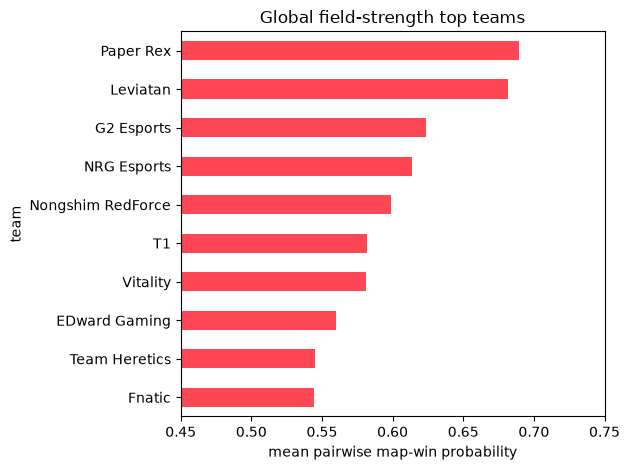

In [7]:
GLOBAL_TEAM_TOP = top_teams_global()
display(GLOBAL_TEAM_TOP.round(ROUND_DIGITS))

ax = GLOBAL_TEAM_TOP.sort_values("field_win_probability").plot.barh(
    x="team_name", y="field_win_probability", legend=False,
    color="#ff4655", title="Global field-strength top teams"
)
ax.set(xlabel="mean pairwise map-win probability", ylabel="team")
ax.set_xlim(0.45, max(0.75, float(GLOBAL_TEAM_TOP["field_win_probability"].max()) + 0.02))
plt.tight_layout()
plt.show()

### 4. Team rankings on every active map

In [8]:
TEAM_MAP_TOP = top_teams_by_map()
TEAM_MAP_GRID = _rank_grid(
    TEAM_MAP_TOP, "map_name", "map_rank", "team_name", "rating"
)
with pd.option_context("display.max_columns", None):
    display(TEAM_MAP_GRID)

print(f"Detailed {MAP_QUERY} table")
display(top_teams_by_map(MAP_QUERY).round(ROUND_DIGITS))

map_name,Ascent,Breeze,Fracture,Haven,Lotus,Pearl,Split
map_rank,,,,,,,
1,Paper Rex (1351.237),Paper Rex (1353.9182),Paper Rex (1352.6161),Paper Rex (1350.9458),Paper Rex (1351.715),Paper Rex (1350.4723),Paper Rex (1352.6628)
2,Leviatan (1336.6463),Leviatan (1332.644),Leviatan (1334.7927),Leviatan (1336.3344),Leviatan (1335.8206),Leviatan (1335.3393),Leviatan (1337.624)
3,G2 Esports (1220.7181),G2 Esports (1222.7538),G2 Esports (1227.1802),G2 Esports (1224.2202),G2 Esports (1224.1621),G2 Esports (1228.8237),G2 Esports (1220.4375)
4,NRG Esports (1205.2405),NRG Esports (1207.7149),NRG Esports (1206.3844),NRG Esports (1206.8762),NRG Esports (1207.5473),NRG Esports (1206.6232),NRG Esports (1204.665)
5,Nongshim RedForce (1177.194),Nongshim RedForce (1191.9561),Nongshim RedForce (1176.2882),Nongshim RedForce (1175.9442),Nongshim RedForce (1177.2031),Nongshim RedForce (1178.1354),Nongshim RedForce (1175.9923)
6,T1 (1149.0481),T1 (1148.6225),T1 (1149.1604),T1 (1149.2947),T1 (1148.1601),T1 (1149.8577),T1 (1149.0663)
7,Vitality (1146.9998),Vitality (1148.3605),Vitality (1146.9746),Vitality (1146.1387),Vitality (1148.1189),Vitality (1148.1884),Vitality (1147.5067)
8,EDward Gaming (1109.8623),EDward Gaming (1110.926),EDward Gaming (1109.4808),EDward Gaming (1108.2774),EDward Gaming (1108.9865),EDward Gaming (1109.1159),EDward Gaming (1109.9978)
9,Team Heretics (1084.1639),Team Heretics (1083.7656),Team Heretics (1083.8112),Team Heretics (1083.4691),Team Heretics (1084.2191),Fnatic (1085.8407),Team Heretics (1082.5665)


Detailed Ascent table


,map_name,map_rank,team_id,team_name,team_slug,rating,uncertainty,ranking_score
0,Ascent,1,32,Paper Rex,PRX,1351.2370,75.0001,1351.2370
1,Ascent,2,24,Leviatan,LEV,1336.6463,75.0001,1336.6463
2,Ascent,3,15,G2 Esports,G2,1220.7181,75.0120,1220.7181
3,Ascent,4,31,NRG Esports,NRG,1205.2405,75.0290,1205.2405
4,Ascent,5,47,Nongshim RedForce,NS,1177.1940,75.4111,1177.1940
5,Ascent,6,36,T1,T1,1149.0481,75.3056,1149.0481
6,Ascent,7,41,Vitality,VIT,1146.9998,75.0013,1146.9998
7,Ascent,8,9,EDward Gaming,EDG,1109.8623,75.0006,1109.8623
8,Ascent,9,19,Team Heretics,TH,1084.1639,75.0124,1084.1639
9,Ascent,10,11,Fnatic,FNC,1080.7607,75.3899,1080.7607


### 5. Player top 10 on every active map

In [9]:
PLAYER_MAP_TOP = top_players_by_map()
PLAYER_MAP_GRID = _rank_grid(
    PLAYER_MAP_TOP, "map_name", "conditional_rank", "player_name", PLAYER_METRIC
)
with pd.option_context("display.max_columns", None):
    display(PLAYER_MAP_GRID)

print(f"Detailed {MAP_QUERY} table")
display(top_players_by_map(MAP_QUERY).round(ROUND_DIGITS))

map_name,Ascent,Breeze,Fracture,Haven,Lotus,Pearl,Split
conditional_rank,,,,,,,
1,Neon (1.4937),Neon (1.5661),Neon (1.1639),Neon (1.5416),Neon (1.7469),Neon (1.5778),Neon (1.3379)
2,Derke (1.1794),Derke (1.3613),mada (0.959),Derke (1.0347),something (1.0021),something (1.0031),something (1.1412)
3,Jemkin (1.1514),t3xture (0.9936),marteen (0.9182),BuZz (0.9207),Jemkin (0.9562),Jemkin (0.974),Derke (0.9809)
4,BuZz (1.0861),iZu (1.0192),BuZz (0.7984),Jemkin (0.8999),mada (0.8612),mada (0.9364),aspas (0.9436)
5,something (1.0722),BuZz (0.9944),Jinggg (0.7511),mada (0.8192),marteen (0.8222),Derke (0.8444),Jemkin (0.9802)
6,t3xture (0.9785),Jemkin (0.9856),aspas (0.7543),ZmjjKK (0.7234),BuZz (0.7066),iZu (0.8229),mada (0.9522)
7,aspas (0.8675),something (0.9348),ara (0.749),dgzin (0.7121),Derke (0.6874),marteen (0.7832),iZu (0.8998)
8,ZmjjKK (0.8558),ZmjjKK (0.8948),Alfajer (0.6915),something (0.6878),ZmjjKK (0.6841),primmie (0.7465),primmie (0.9314)
9,mada (0.85),dgzin (0.9321),Jemkin (0.7008),iZu (0.6678),Alfajer (0.5894),aspas (0.6832),marteen (0.8487)


Detailed Ascent table


,map_name,conditional_rank,player_id,player_name,team_name,performance_z_score,performance_rounds_per_24,standard_deviation,standard_deviation_z,interval80_low,interval80_high,support,ranking_score
0,Ascent,1,30966,Neon,Leviatan,1.4937,0.5562,6.3682,24.0393,-7.6050,8.7174,observed,-10.5260
1,Ascent,2,487,Derke,Vitality,1.1794,0.4730,6.3297,23.8939,-7.6388,8.5848,observed,-10.7675
2,Ascent,3,7947,Jemkin,Rex Regum Qeon,1.1514,0.4656,6.3337,23.9089,-7.6513,8.5825,observed,-10.8030
3,Ascent,4,78,BuZz,T1,1.0861,0.4483,6.3199,23.8571,-7.6511,8.5476,partially-pooled,-10.8424
4,Ascent,5,1057,something,Paper Rex,1.0722,0.4446,6.3253,23.8774,-7.6616,8.5508,observed,-10.8665
5,Ascent,6,409,t3xture,Gen.G,0.9785,0.4198,6.3115,23.8253,-7.6688,8.5083,partially-pooled,-10.9342
6,Ascent,7,168,aspas,MIBR,0.8675,0.3904,6.2991,23.7783,-7.6822,8.4629,partially-pooled,-11.0217
7,Ascent,8,457,ZmjjKK,EDward Gaming,0.8558,0.3873,6.3235,23.8707,-7.7167,8.4912,partially-pooled,-11.0795
8,Ascent,9,18052,mada,NRG Esports,0.8500,0.3857,6.3558,23.9925,-7.7596,8.5310,observed,-11.1463
9,Ascent,10,23361,ara,GIANTX,0.8113,0.3755,6.3564,23.9945,-7.7705,8.5215,observed,-11.1860


### 6. Player top 10 for every legal agent

The compact grid uses the active publication view and shows all agents.
The detailed selected-agent table also shows support, recent maps played,
and the player's model-predicted probability of using that agent averaged
across active maps. Pass `agent_view="forced-counterfactual"` explicitly to
inspect the full grid; it is never the default for a v4/v5 bundle.

In [10]:
PLAYER_AGENT_TOP = top_players_by_agent()
PLAYER_AGENT_GRID = _rank_grid(
    PLAYER_AGENT_TOP, "agent", "conditional_rank", "player_name", PLAYER_METRIC
)
with pd.option_context("display.max_columns", None):
    display(PLAYER_AGENT_GRID)

print(f"Detailed {AGENT_QUERY} table")
display(top_players_by_agent(AGENT_QUERY).round(ROUND_DIGITS))

Active player-agent view: demonstrated


agent,Astra,Breach,Brimstone,Chamber,Clove,Cypher,Deadlock,Fade,Gekko,Harbor,Iso,Jett,KAY/O,Killjoy,Neon,Omen,Phoenix,Raze,Reyna,Sage,Skye,Sova,Tejo,Veto,Viper,Vyse,Waylay,Yoru
conditional_rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,kiNgg (0.2498),invy (-0.7483),Neon (0.6455),Neon (2.8145),keznit (-0.5671),iZu (0.7028),primmie (0.0464),blowz (-0.2274),iZu (-0.04),mada (-0.1834),Alfajer (0.5397),Neon (2.8144),invy (-0.4772),iZu (0.8421),mada (1.294),Neon (0.701),Derke (0.8036),iZu (1.2835),SpiritZ1 (0.0109),invy (0.3156),invy (-0.2467),iZu (0.1921),iZu (-0.0849),something (0.9579),happywei (0.6049),Alfajer (0.5351),mada (1.4586),Neon (2.1281)
2,happywei (0.1265),Chronicle (-1.0516),something (0.0955),iZu (2.1499),NaN,happywei (0.5947),Ivy (-0.0907),invy (-0.3785),invy (-0.1021),PROFEK (-0.3271),ZmjjKK (0.2798),Derke (2.2312),stax (-0.6943),Alfajer (0.6914),iZu (1.3019),iZu (-0.1076),primmie (0.7129),mada (1.1812),Demon1 (-0.3207),Alfajer (0.2629),blowz (-0.3677),invy (0.0094),Alfajer (-0.2267),happywei (0.9399),Alfajer (0.5894),Chronicle (0.3323),iZu (1.2703),iZu (1.6772)
3,PROFEK (-0.0163),kiNgg (-1.0352),PROFEK (0.0551),invy (2.0511),NaN,Alfajer (0.4856),saadhak (-0.1051),RieNs (-0.5392),something (-0.1648),f0rsakeN (-0.4933),Meteor (0.1228),something (2.1216),spike (-0.6236),keiko (0.611),Derke (1.1333),spike (-0.1102),marteen (0.6911),Alfajer (1.1434),NaN,mada (0.2503),f0rsakeN (-0.6127),something (-0.058),trent (-0.4555),Chronicle (0.8303),kiNgg (0.4927),happywei (0.2934),something (1.1897),mada (1.4559)
4,valyn (-0.2132),Ethan (-1.2516),invy (0.0517),Jemkin (2.0071),NaN,Less (0.4044),brawk (-0.0933),eeiu (-0.532),RieNs (-0.4888),kiNgg (-0.4501),vo0kashu (0.0056),Jemkin (1.9209),saadhak (-0.7699),Chronicle (0.6076),ZmjjKK (1.0955),Jinggg (-0.191),keiko (0.662),Derke (1.0653),NaN,happywei (0.2264),d4v41 (-0.7227),brawk (-0.1099),blowz (-0.3793),f0rsakeN (0.7509),Chronicle (0.4702),kiNgg (0.2669),primmie (1.167),primmie (1.3873)
5,keiko (-0.1539),Jamppi (-1.3756),kiNgg (-0.116),Alfajer (1.9679),NaN,saadhak (0.2949),Kr1stal (-0.3168),crashies (-0.5982),PatMen (-0.562),valyn (-0.5278),jawgemo (-0.0248),primmie (1.9277),Ethan (-0.8264),d4v41 (0.5088),spike (1.1196),PROFEK (-0.192),Sato (0.5644),Jinggg (1.0401),NaN,Jinggg (0.1163),trent (-0.687),trent (-0.1553),brawk (-0.4911),marteen (0.7578),PROFEK (0.5199),keiko (0.287),Derke (1.0686),Derke (1.326)
6,f0rsakeN (-0.2173),leaf (-1.3759),keiko (-0.1676),happywei (1.9885),NaN,cortezia (0.277),leaf (-0.3468),stax (-0.612),Jamppi (-0.688),saadhak (-0.5694),Reduxx (0.0395),mada (1.8606),Veqaj (-0.921),Kr1stal (0.5621),Alfajer (1.1317),keiko (-0.24),Timotino (0.5621),BuZz (1.0408),NaN,primmie (0.1439),stax (-0.7582),blowz (-0.1246),stax (-0.4873),leaf (0.4847),keiko (0.5159),brawk (0.2566),Alfajer (1.0778),something (1.2919)
7,Ivy (-0.2007),nephh (-1.4892),f0rsakeN (-0.2338),something (1.9624),NaN,hiro (0.2279),Smoggy (-0.4371),trent (-0.6439),nobody (-0.7262),Rb (-0.616),Wo0t (-0.1275),keiko (1.8004),Rb (-0.8707),cortezia (0.4598),Jemkin (1.0919),saadhak (-0.2598),Jinggg (0.4283),keiko (1.0472),NaN,Chronicle (0.0873),lucas (-0.7311),Xross (-0.0951),d4v41 (-0.5163),xffero (0.4079),Less (0.4306),d4v41 (0.1325),BuZz (1.056),marteen (1.3288)
8,Rb (-0.283),crazyguy (-1.5593),marteen (-0.1753),Chronicle (1.9111),NaN,Ivy (0.2697),nephh (-0.4295),f0rsakeN (-0.6427),Killua (-0.8062),Ethan (-0.6124),Autumn (-0.0915),BuZz (1.6977),Jamppi (-1.0024),Ivy (0.4563),BuZz (0.9929),happywei (-0.329),Dambi (0.5048),primmie (1.0804),NaN,Rarga (0.1045),Xross (-0.7244),RieNs (-0.2535),Ethan (-0.5917),Cryocells (0.3646),Ivy (0.4703),cortezia (0.1516),Jemkin (1.0339),Jemkin (1.246)
9,slowly (-0.2393),Francis (-1.5494),brawk (-0.218),ZmjjKK (1.8366),NaN,Chronicle (0.1846),Autumn (-0.4653),Ethan (-0.6579),crazyguy (-0.8609),lukxo (-0.6306),artzin (-0.1473),ZmjjKK (1.6452),Munchkin (-1.072),hiro (0.4431),Jinggg (1.0142),f0rsakeN (-0.4605),ZmjjKK (0.445),Timotino (1.0388),NaN,d4v41 (-0.0156),crashies (-0.8829),f0rsakeN (

Detailed Jett table
Active player-agent view: demonstrated


,agent,conditional_rank,player_id,player_name,team_name,performance_z_score,performance_rounds_per_24,standard_deviation,standard_deviation_z,interval80_low,interval80_high,support,maps_played,predicted_agent_use_probability,publication_view,ranking_score
0,Jett,1,30966,Neon,Leviatan,2.8144,0.8772,6.3440,24.6228,-7.2530,9.0073,observed,11,0.1336,demonstrated,-9.4970
1,Jett,2,487,Derke,Vitality,2.2312,0.7269,6.3017,24.4588,-7.3491,8.8029,observed,17,0.1966,demonstrated,-9.9982
2,Jett,3,1057,something,Paper Rex,2.1216,0.6987,6.2870,24.4016,-7.3584,8.7557,observed,32,0.2643,demonstrated,-10.0792
3,Jett,4,7947,Jemkin,Rex Regum Qeon,1.9209,0.6469,6.3180,24.5221,-7.4499,8.7438,observed,10,0.1797,demonstrated,-10.3401
4,Jett,5,16096,primmie,FULL SENSE,1.9277,0.6487,6.3311,24.5730,-7.4650,8.7624,observed,11,0.1513,demonstrated,-10.3588
5,Jett,6,18052,mada,NRG Esports,1.8606,0.6314,6.3310,24.5725,-7.4821,8.7449,observed,9,0.0970,demonstrated,-10.4257
6,Jett,7,7541,keiko,NRG Esports,1.8004,0.6159,6.3239,24.5450,-7.4885,8.7203,observed,7,0.0668,demonstrated,-10.4721
7,Jett,8,78,BuZz,T1,1.6977,0.5894,6.3002,24.4531,-7.4846,8.6635,observed,6,0.2031,demonstrated,-10.5289
8,Jett,9,457,ZmjjKK,EDward Gaming,1.6452,0.5759,6.2931,24.4254,-7.4890,8.6408,observed,27,0.2645,demonstrated,-10.5676
9,Jett,10,106,Jinggg,Paper Rex,1.6754,0.5837,6.3301,24.5688,-7.5286,8.6960,partially-pooled,3,0.0289,demonstrated,-10.6091


### 7. Look up one player by name

`show_player_map_ratings(name)` and `show_player_agent_ratings(name)`
both display and return the underlying DataFrame. Partial names work only
when they resolve to exactly one active player; ambiguous matches list IDs.

In [11]:
def player_map_profile(name_or_id, metric=None, allowed_support=None,
                       uncertainty_penalty=None):
    player = resolve_player(name_or_id)
    selected_metric = _player_metric(metric)
    ranked, _ = _rank_player_view(
        "map", "map_name", selected_metric, allowed_support, uncertainty_penalty
    )
    result = ranked.loc[ranked["player_id"].eq(int(player["player_id"]))].copy()
    overall = player_ratings.loc[
        player_ratings["player_id"].eq(int(player["player_id"]))
        & player_ratings["view"].eq("overall"), selected_metric
    ]
    overall_value = float(overall.iloc[0]) if not overall.empty else np.nan
    result["delta_vs_overall"] = result[selected_metric] - overall_value
    columns = [
        "map_name", "conditional_rank", selected_metric, "delta_vs_overall",
        "performance_rounds_per_24", "performance_z_score",
        "standard_deviation", "standard_deviation_z",
        "interval80_low", "interval80_high", "support"
    ]
    return result[list(dict.fromkeys(columns))].reset_index(drop=True)


def player_agent_profile(name_or_id, metric=None, allowed_support=None,
                         uncertainty_penalty=None, min_agent_use_probability=None,
                         agent_view=None):
    player = resolve_player(name_or_id)
    selected_metric = _player_metric(metric)
    selected_agent_view = _player_agent_view(agent_view)
    print("Active player-agent view:", selected_agent_view)
    minimum = (
        MIN_AGENT_USE_PROBABILITY
        if min_agent_use_probability is None
        else float(min_agent_use_probability)
    )
    ranked, _ = _rank_player_view(
        "agent", "agent", selected_metric, allowed_support,
        uncertainty_penalty, minimum, selected_agent_view
    )
    result = ranked.loc[ranked["player_id"].eq(int(player["player_id"]))].copy()
    overall = player_ratings.loc[
        player_ratings["player_id"].eq(int(player["player_id"]))
        & player_ratings["view"].eq("overall"), selected_metric
    ]
    overall_value = float(overall.iloc[0]) if not overall.empty else np.nan
    result["delta_vs_overall"] = result[selected_metric] - overall_value
    columns = [
        "agent", "conditional_rank", selected_metric, "delta_vs_overall",
        "performance_rounds_per_24", "performance_z_score",
        "standard_deviation", "standard_deviation_z",
        "interval80_low", "interval80_high", "support",
        "maps_played", "predicted_agent_use_probability", "publication_view",
        "ranking_score"
    ]
    return result[list(dict.fromkeys(columns))].sort_values(
        "conditional_rank", kind="stable"
    ).reset_index(drop=True)


def show_player_map_ratings(name_or_id, **kwargs):
    player = resolve_player(name_or_id)
    frame = player_map_profile(name_or_id, **kwargs)
    display(Markdown(
        f"#### {player['player_name']} - ratings by map ({player['team_name']})"
    ))
    display(frame.round(ROUND_DIGITS))
    return frame


def show_player_agent_ratings(name_or_id, **kwargs):
    player = resolve_player(name_or_id)
    agent_kwargs = dict(kwargs)
    selected_agent_view = _player_agent_view(agent_kwargs.get("agent_view"))
    agent_kwargs["agent_view"] = selected_agent_view
    frame = player_agent_profile(name_or_id, **agent_kwargs)
    display(Markdown(
        f"#### {player['player_name']} - ratings by agent ({player['team_name']}; "
        f"view: {selected_agent_view})"
    ))
    display(frame.round(ROUND_DIGITS))
    return frame


def show_player_ratings(name_or_id, **kwargs):
    map_kwargs = {
        key: value
        for key, value in kwargs.items()
        if key in {"metric", "allowed_support", "uncertainty_penalty"}
    }
    maps = show_player_map_ratings(name_or_id, **map_kwargs)
    agents = show_player_agent_ratings(name_or_id, **kwargs)
    selected_metric = _player_metric(kwargs.get("metric"))
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    maps.sort_values(selected_metric).plot.barh(
        x="map_name", y=selected_metric, legend=False, color="#ff4655", ax=axes[0],
        title="Map-conditioned rating"
    )
    agents.head(12).sort_values(selected_metric).plot.barh(
        x="agent", y=selected_metric, legend=False, color="#0f9d8a", ax=axes[1],
        title="Top 12 agent-conditioned ratings"
    )
    axis_label = (
        "Predictive Box VPM (development-population SDs)"
        if selected_metric == "performance_z_score"
        else "Predictive Box VPM (rounds per 24)"
    )
    axes[0].set(xlabel=axis_label, ylabel="map")
    axes[1].set(xlabel=axis_label, ylabel="agent")
    plt.tight_layout()
    plt.show()
    return {"map": maps, "agent": agents}

#### something - ratings by map (Paper Rex)

,map_name,conditional_rank,performance_z_score,delta_vs_overall,performance_rounds_per_24,standard_deviation,standard_deviation_z,interval80_low,interval80_high,support
0,Ascent,5,1.0722,0.0905,0.4446,6.3253,23.8774,-7.6616,8.5508,observed
1,Breeze,7,0.9348,-0.0469,0.4082,6.3398,23.9322,-7.7166,8.5330,observed
2,Fracture,26,0.3575,-0.6243,0.2553,6.3473,23.9603,-7.8791,8.3896,observed
3,Haven,8,0.6878,-0.2939,0.3428,6.3264,23.8814,-7.7648,8.4504,observed
4,Lotus,2,1.0021,0.0204,0.4260,6.3081,23.8124,-7.6581,8.5102,observed
5,Pearl,2,1.0031,0.0214,0.4263,6.3147,23.8372,-7.6663,8.5188,observed
6,Split,2,1.1412,0.1595,0.4629,6.3147,23.8372,-7.6297,8.5555,observed


Active player-agent view: demonstrated


#### something - ratings by agent (Paper Rex; view: demonstrated)

,agent,conditional_rank,performance_z_score,delta_vs_overall,performance_rounds_per_24,standard_deviation,standard_deviation_z,interval80_low,interval80_high,support,maps_played,predicted_agent_use_probability,publication_view,ranking_score
0,Veto,1,0.9579,-0.0238,0.3988,6.3743,24.7406,-7.7702,8.5679,partially-pooled,1,0.0139,demonstrated,-11.4124
1,Brimstone,2,0.0955,-0.8863,0.1766,6.3581,24.6777,-7.9716,8.3249,partially-pooled,4,0.0534,demonstrated,-12.2434
2,Gekko,3,-0.1648,-1.1465,0.1096,6.3374,24.5975,-8.0122,8.2313,partially-pooled,1,0.0318,demonstrated,-12.4635
3,Jett,3,2.1216,1.1399,0.6987,6.2870,24.4016,-7.3584,8.7557,observed,32,0.2643,demonstrated,-10.0792
4,Sova,3,-0.0580,-1.0397,0.1371,6.3321,24.5767,-7.9778,8.2520,observed,5,0.0179,demonstrated,-12.3464
5,Waylay,3,1.1897,0.2080,0.4586,6.3446,24.6253,-7.6724,8.5895,observed,8,0.0250,demonstrated,-11.1229
6,Yoru,6,1.2919,0.3102,0.4849,6.2970,24.4405,-7.5850,8.5548,observed,63,0.1731,demonstrated,-10.9283
7,Chamber,7,1.9624,0.9806,0.6576,6.3541,24.6621,-7.4855,8.8007,partially-pooled,1,0.0167,demonstrated,-10.3687
8,Neon,11,1.0044,0.0227,0.4108,6.3331,24.5807,-7.7054,8.5270,partially-pooled,3,0.0302,demonstrated,-11.2859


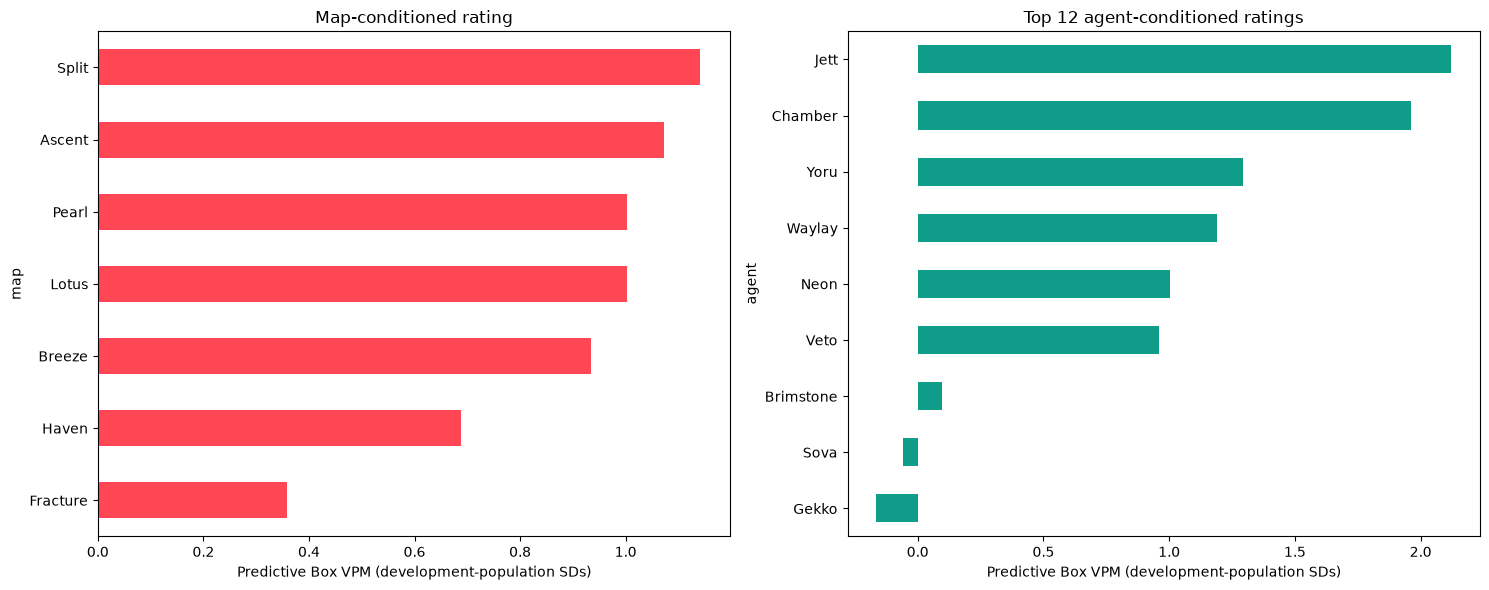

In [12]:
PLAYER_PROFILE = show_player_ratings(PLAYER_QUERY)

## Checks

These checks protect the ranking grain, lookup joins, intervals, and
probability normalization. If an edited filter leaves fewer than ten
eligible players, that is reported rather than silently filled with a
different support class.

In [13]:
checks = {
    "unique global team rows": not global_teams["team_id"].duplicated().any(),
    "unique team-map rows": not team_ratings.loc[team_ratings["view"].eq("map")].duplicated(
        ["team_id", "map_name"]
    ).any(),
    "unique player rating cells": not player_ratings_raw.duplicated(
        ["player_id", "view", "map_name", "agent"]
    ).any(),
    "unique demonstrated player-agent cells": (
        not player_agent_ratings_raw_by_view["demonstrated"].duplicated(
            ["player_id", "team_id", "agent"]
        ).any()
        if "demonstrated" in player_agent_ratings_raw_by_view
        else True
    ),
    "unique forced-counterfactual player-agent cells": (
        not player_agent_ratings_raw_by_view["forced-counterfactual"].duplicated(
            ["player_id", "team_id", "agent"]
        ).any()
        if "forced-counterfactual" in player_agent_ratings_raw_by_view
        else True
    ),
    "unique player-agent publication cells": not player_agent_ratings_raw.duplicated(
        ["player_id", "team_id", "agent", "publication_view"]
    ).any(),
    "publication labels match artifacts": all(
        frame["publication_view"].eq(view).all()
        for view, frame in player_agent_ratings_raw_by_view.items()
    ),
    "demonstrated cells have recent maps": (
        player_agent_ratings_raw_by_view["demonstrated"]["maps_played"].gt(0).all()
        if "demonstrated" in player_agent_ratings_raw_by_view
        else True
    ),
    "forced-counterfactual cells are explicitly flagged": (
        player_agent_ratings_raw_by_view["forced-counterfactual"][
            "is_forced_counterfactual"
        ].eq(True).all()
        if "forced-counterfactual" in player_agent_ratings_raw_by_view
        else True
    ),
    "v4/v5 default player-agent view is demonstrated": (
        PLAYER_AGENT_ARTIFACT_MODE not in {"dedicated-v4", "dedicated-v5"}
        or ACTIVE_PLAYER_AGENT_VIEW == "demonstrated"
    ),
    "v5 performance display is finite": (
        PLAYER_AGENT_ARTIFACT_MODE != "dedicated-v5"
        or (
            np.isfinite(player_ratings["performance_z_score"]).all()
            and np.isfinite(player_ratings["performance_rounds_per_24"]).all()
        )
    ),
    "field probabilities in [0, 1]": bool(global_teams["field_win_probability"].between(0, 1).all()),
    "nonnegative uncertainty": bool(
        player_ratings["standard_deviation"].ge(0).all()
        and player_agent_ratings["standard_deviation"].ge(0).all()
        and team_ratings["uncertainty"].ge(0).all()
    ),
    "means inside 80% intervals": bool(
        player_ratings["performance_mean"].between(
            player_ratings["interval80_low"], player_ratings["interval80_high"]
        ).all()
    ),
    "known support labels": (
        set(player_ratings["support"]).issubset(SUPPORT_VALUES)
        and set(player_agent_ratings["support"]).issubset(SUPPORT_VALUES)
    ),
    "all active names joined": bool(
        global_teams["team_name"].notna().all()
        and player_ratings["player_name"].notna().all()
        and player_agent_ratings["player_name"].notna().all()
    ),
    "agent probabilities sum to one": bool(
        np.allclose(
            agent_probabilities.groupby(["player_id", "team_id", "map_name"])["probability"].sum(),
            1.0,
        )
    ),
    "default player resolves once": int(resolve_player(PLAYER_QUERY)["player_id"]) > 0,
    "player map profile covers active maps": set(player_map_profile(PLAYER_QUERY)["map_name"]) == set(ACTIVE_MAPS),
}
check_frame = pd.Series(checks, name="passed").to_frame()
display(check_frame)
assert check_frame["passed"].all(), check_frame.loc[~check_frame["passed"]].index.tolist()

map_counts = PLAYER_MAP_TOP.groupby("map_name").size()
agent_counts = PLAYER_AGENT_TOP.groupby("agent").size()
if (map_counts < TOP_N).any():
    print("Maps with fewer eligible players than TOP_N:", map_counts[map_counts < TOP_N].to_dict())
if (agent_counts < TOP_N).any():
    print("Agents with fewer eligible players than TOP_N:", agent_counts[agent_counts < TOP_N].to_dict())
print("All explorer checks passed.")

,passed
unique global team rows,True
unique team-map rows,True
unique player rating cells,True
unique demonstrated player-agent cells,True
unique forced-counterfactual player-agent cells,True
unique player-agent publication cells,True
publication labels match artifacts,True
demonstrated cells have recent maps,True
forced-counterfactual cells are explicitly flagged,True
v4/v5 default player-agent view is demonstrated,True


Agents with fewer eligible players than TOP_N: {'Clove': 1, 'Reyna': 2}
All explorer checks passed.


## Next steps

Useful calls to try in a new cell:

```python
top_teams_by_map("Lotus", n=20)
top_players_by_agent("Raze", allowed_support=("observed", "partially-pooled"))
top_players_by_agent("Jett", min_agent_use_probability=0.10)
top_players_by_agent("Sova", agent_view="forced-counterfactual")
show_player_ratings("ZmjjKK")
show_player_map_ratings(1057)
```

To change fitted Elo, player-model, or prior parameters, create a new
versioned development/scoring experiment and compare it out of sample.
This explorer intentionally keeps those frozen.